# Quasi 1-dimensional Euler equations for Perfect Ideal Gas


Unsteady Euler equations for quasi-1 dimensional flows read

$$
  \partial_t \begin{bmatrix} \rho A \\ \rho u A \\ \rho e^t A \end{bmatrix} +
  \partial_z \begin{bmatrix} \rho u A \\ \frac{( \rho u A )^2}{\rho A} + p A \\ \frac{ (\rho e^t A + p A) (\rho u A) }{ \rho A }  \end{bmatrix}
  = \begin{bmatrix} 0 \\ p \partial_z A \\ 0 \end{bmatrix}
$$


**Method 1.** The same conservative variables as the 1-dimensional flow solver are used $(\rho, m, E^t)$, and non-uniform
- appears as a source in momentum equation
- appears in discretization for cells $A_i$ and as a factor multiplying fluxes $A_{i+1/2} F_{i+1/2}$

   $$\mathbf{u}_i^{n+1} = \mathbf{u}_i^{n} - \frac{\Delta t}{\Delta A_i} \left( \mathbf{F}_{i+1/2} A_{i+1/2} - \mathbf{F}_{i-1/2} A_{i-1/2} \right) + \Delta t \, \mathbf{s}_i$$

**Method 2.** Another approach would be using $(\rho A, m A, E^t A)$  as conservative variables.

**todo**

## Useful classes for numerical methods

### Basic libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Parent class

$\texttt{HyperbolicSystem1d()}$ class with common functions (or just their templates) required to implement a finite volume method solver.


In [2]:
class HyperbolicSystem1d():
    """
    Analytical quantities of a Hyperbolic linear system in a 1-dimensional domain
    """
    def __init(self, **params):
        pass
    def flux(self,):
        """ Analytical flux, f """
        pass
    def A(self,):
        """ Advection matrix, A """
        pass
    def s(self,):
        """ Eigenvalues of matrix, s """
        pass
    def R(self,):
        """ Matrix of right eigenvectors, R """
        pass
    def L(self,):
        """ Matrix of left eigenvectors, L=inv(R) """
        pass
    def spectrum(self,):
        """ Spectrum of matrix A() """
        return self.s(), self.R(), self.L()

    def absA(self, u):
        """ A = R * S * L, |A| = R * |S| * L """
        return self.R(u) @ np.diag(np.abs(self.s(u))) @ self.L(u)

    def roe_intermediate_state(self,):
        """ Roe intermediate state for Roe linearization """
        pass



### Euler equations for perfect ideal gas class

In [3]:
class Euler1dPIG(HyperbolicSystem1d):
    """
    Analytical quantities of a Hyperbolic linear system in a 1-dimensional domain
    Physical quantities:
    - conservative: (rho, m, Et)
    - physical/convective (rho, u, e) or (rho, u, s)
    Parameters:
    - gamma: cp/cv ratio

    PIG (Perfect Ideal Gas)
    gamma = cp / cv  --> cv =     1 / ( gamma - 1 ) * R
    cp - cv = R      --> cp = gamma / ( gamma - 1 ) * R
    p = rho * R * T = rho * R/cv e = (gamma-1) * rho * e = (gamma-1) * E
    e = cv * T
    """
    def __init__(self, gamma=5./3., name=""):
        """  """
        # Speed of sound, a, and pressure, p,  are functions of the TD state
        # ...add functions fun_a(...), fun_p(...)
        # - which physical variables?
        # - equations of state for different fluids (PIG, VdW,...)
        self.gamma = gamma
        self.gamma_1 = self.gamma - 1
        self.name = name

    def fun_p(self, u):
        """
        Pressure as a function of conservative variables
        p = rho R T = rho R/cv e = (gamma-1) rho e = (gamma-1) ( Et - .5* m^2/rho)
        """
        return self.gamma_1 * ( u[2] - .5 * u[1]**2 / u[0] )

    def phys_from_cons(self, u):
        """
        rho = rho
        u   = m / rho
        p   = (gamma-1) * E
            = (gamma-1) * ( Et - .5 * rho * u^2 )
            = (gamma-1) * ( Et - .5 * m^2 / rho )
        """
        return np.array([ u[0], u[1]/u[0], self.fun_p(u) ])

    def cons_from_phys(self, p):
        """
        rho = rho
        m   = rho * u
        Et  = rho * ( e + .5 * u^2 )
            = E + .5 * rho * u^2
            = p / ( gamma - 1 ) + .5 * rho * u^2
        """
        Et = p[2]/self.gamma_1 + .5 * p[0] * p[1]**2
        return np.array([ p[0], p[0]*p[1], Et])

    def flux(self, u):
        """ Numerical flux
        u: conservative variables (rho, m, Et)
        F = ( m, rho*u^2+p(...), u*(Et+p(...)) )
        """
        vel = u[1]/u[0]
        p = self.fun_p(u)
        return np.array([ u[1], u[0]*vel**2+p, vel*(u[2]+p) ])

    def A(self, u):
        """
        Convection matrix, A; input: conservative variables
        A = [[            0,        1,         0 ],
             [    u^2+p_rho,   2u+p_m,      p_Et ],
             [-u*ht+u*p_rho, ht+u*p_m, u*(1+p_Et)]]
        """
        vel = u[1]/u[0]
        p = self.fun_p(u)
        ht = ( u[2] + p ) / u[0]
        p_rho = .5 * self.gamma_1 * vel**2
        p_m   = - self.gamma_1 * vel
        p_Et  =   self.gamma_1
        return np.array(
            [[ .0, 1.,.0 ],
             [ -vel**2+p_rho, 2*vel+p_m, p_Et ],
             [  vel*(-ht+p_rho), ht+vel*p_m, vel*(1+p_Et) ]])

    def s(self, u):
        """
        Eigenvalues of A; input: conservative variables
        s = [u-a, u, u+a]
        """
        vel = u[1]/u[0]
        p = self.fun_p(u)
        # Speed of sound, a^2 = gamma R T = gamma p / rho
        a = np.sqrt(self.gamma * self.fun_p(u)/u[0])
        return np.array([vel-a, vel, vel+a])

    def R(self, u):
        """
        Right eigenvectors of A; input: conservative variables
        R = ...
        """
        vel = u[1]/u[0]
        p = self.fun_p(u)
        # Speed of sound, a^2 = gamma R T = gamma p / rho
        a = np.sqrt(self.gamma * self.fun_p(u)/u[0])
        ht = ( u[2] + p ) / u[0]
        p_rho = .5 * self.gamma_1 * vel**2
        p_m   = - self.gamma_1 * vel
        p_Et  =   self.gamma_1

        return np.array([
            [1, vel-a, ht-vel*a],
            [1, vel  , vel**2-p_rho/p_Et],
            [1, vel+a, ht+vel*a]]).T

    def L(self, u):
        """
        Left eigenvectors of A; input: conservative variables
        L = ...
        """
        vel = u[1]/u[0]
        p = self.fun_p(u)
        # Speed of sound, a^2 = gamma R T = gamma p / rho
        a = np.sqrt(self.gamma * self.fun_p(u)/u[0])
        ht = ( u[2] + p ) / u[0]
        p_rho = .5 * self.gamma_1 * vel**2
        p_m   = - self.gamma_1 * vel
        p_Et  =   self.gamma_1

        return np.array([
            [ p_rho + vel*a ,   p_m - a  ,   p_Et ],
            [-2*(p_rho-a**2),-2*p_m      ,-2*p_Et ],
            [ p_rho - vel*a ,   p_m + a  ,   p_Et ]
            ]) / ( 2. * a**2 )

    def spectrum(self, u):
        """ Spectrum of matrix A; input: conservative variables """
        return self.s(u), self.R(u), self.L(u)

    def roe_intermediate_state(self, u_0, u_1):
        """
        For p-sys:
          rho_roe = ANY! = ... CHOOSE ONE: average = 0.5*(rho_0+rho_1)
          vel_roe = (sqrt(rho_0)*vel_0+sqrt(rho_1)*vel_1)/(sqrt(rho_0)+sqrt(rho_1))
          - convective/physical: (rho, vel) = ( rho_roe, vel_roe )
          - conservatvie       : (rho, mom) = ( rho_roe, rho_roe*vel_roe)
          F_roe(u) ~ dFdu * du ~ A(u_roe(u0,u1)) * (u_1 - u_0)
        """
        #> Density (for a PIG, it's arbitrary once consistency is provided)
        rho_roe = .5*(u_0[0]+u_1[0])

        vel_0, vel_1 = u_0[1]/u_0[0], u_1[1]/u_1[0]
        p_0, p_1 = self.fun_p(u_0), self.fun_p(u_1)
        ht_0, ht_1 = ( u_0[2] + p_0 ) / u_0[0],  ( u_1[2] + p_1 ) / u_1[0]

        #> Velocity and total enthalpy (Roe linearization)
        vel_roe = (vel_0*np.sqrt(u_0[0])+vel_1*np.sqrt(u_1[0])) / \
                  (np.sqrt(u_0[0])+np.sqrt(u_1[0]))
        ht_roe  = ( ht_0*np.sqrt(u_0[0])+ ht_1*np.sqrt(u_1[0])) / \
                  (np.sqrt(u_0[0])+np.sqrt(u_1[0]))

        #> Enthalpy and pressure (PIG)
        h_roe = ht_roe - .5 * vel_roe**2
        # p = rho R T = rho R/cP h = (gamma-1)/gamma * rho * h
        p_roe = self.gamma_1/self.gamma * rho_roe * h_roe

        #> Momentum and total energy
        m_roe = rho_roe * vel_roe
        Et_roe = rho_roe * ht_roe - p_roe

        return np.array([rho_roe, m_roe, Et_roe])

    def absA_entropy_fix(self, u, delta=.1):
        """  """
        #> Eigenvalues s1 = u-a, s2 = u, s3 = u+a
        eigvals = self.s(u)
        #> Speed of sound a = .5 * ( s3 - s1 )
        a = .5 * ( np.max(eigvals) - np.min(eigvals) )
        #> Entropy fix
        entropy_evals = np.abs(eigvals)
        entropy_evals[entropy_evals < delta*a] = \
            .5 * entropy_evals[entropy_evals < delta*a]**2 / ( delta * a ) + .5 * ( delta * a )

        return  self.R(u) @ np.diag(entropy_evals) @ self.L(u)

    def roe_flux(self, u_0, u_1):
        """  """
        u_roe = self.roe_intermediate_state(u_0, u_1)

        return .5 * (self.flux(u_1) + self.flux(u_0) + \
                     self.absA_entropy_fix(u_roe) @ ( u_0 - u_1 ) )

    def flux_at_boundary(self, boundary, u):
        """
        boundary: boundary conditino dict
        u: conservative variables (rho, m, Et) at boundary cell
        """

        if ( boundary["type"] == "wall" ):
            u_boundary = u.copy(); u_boundary[1] = -u[1]
            if ( boundary["nor"] < 0 ):
                return self.roe_flux(u_boundary, u)
            else:
                return self.roe_flux(u, u_boundary)

        elif ( boundary["type"] == "inflow" or boundary["type"] == "outflow" ):
            delta_v = self.L(u) @ ( self.cons_from_phys(boundary["phys_ext"]) - u )
            eigval = self.s(u)
            delta_v[ eigval*boundary["nor"] > 0 ] = .0
            u_flux = u + self.R(u) @ delta_v

            return self.flux(u_flux)



## Numerical simulation

### System of equations

Initialized the system of equations to be solved

In [4]:
# Number of unknown fields, nu
#> P-system, Shallow Water
#  - conservative       : u = (rho, mom)
#  - physical/convective: p = (rho, vel), with mom = rho*vel
#> Euler
#  - conservative       : u = (rho, mom, Et)
#  - physical/convective: p = (rho, vel, e) or = (rho, vel, s), with mom = rho*vel

gamma = 5. / 3.

#> Area
# A(x) = a + b * cos(2*pi*x)
# Amax = a + b
# Amin = a - b
# a = ( Amax + Amin ) / 2
# b = ( Amax - Amin ) / 2
A_min_max_ratio = 1. / 2
a_coeff = .5 * ( 1 + A_min_max_ratio )
b_coeff = .5 * ( 1 - A_min_max_ratio )
A_fun  = lambda x: a_coeff + b_coeff * np.cos(2 * np.pi * x)
dA_fun = lambda x: -2. * np.pi * b_coeff * np.sin(2 * np.pi * x)

#> Parameters and initialization of the system
# S = Psys1d(a=1);  nu = 2
# S = ShallowWater1d(g=1);  nu = 2
# S = Psys1dLinearized(a=1);  nu = 2
S = Euler1dPIG(gamma=gamma,);  nu = 3


### Domain

In [5]:
#> Parameters
x0, x1 = 0., 1.                          # coords of left and right boundaries
ne = 50                                  # n. of elements

#> Domain
xs = np.linspace(x0, x1, ne+1)           # coord of the cell boundaries
xc = .5 * ( xs[:-1] + xs[1:] )           # coord of the cell centers
dx = xs[1:] - xs[:-1]                    # volume of the cells

#> Quasi-1 dimensional flows
A_cell = A_fun(xc)
dA_cell = dA_fun(xc)
A_face = A_fun(xs)


### Boundary conditions

In [6]:
#> Boundary conditions

# boundary_0 = {  # left boundary
#     "type": "wall",
#     "nor" : -1.
# }
# boundary_1 = {  # right boundary
#     "type": "wall",
#     "nor" : 1.
# }
boundary_0 = {  # left boundary
    "type": "inflow",
    "phys_ext": np.array([1., 1.2, .5]),   # rho_ext, u_ext, p_ext
    "nor": -1.                             # nx
}
boundary_1 = {  # right boundary
    "type": "outflow",
#   "phys_ext": [ rho_ext, u_ext, p_ext ],
#   "phys_ext": np.array([.1, .0, .1]),    # 0. No shock in the divergent
#   "phys_ext": np.array([.5, .0, .5]),    # 1. Shock in the divergent at x~0.9
    "phys_ext": np.array([.75, .0, .75]),  # 2. Shock in the divergent at x~0.7
#   "phys_ext": np.array([1., .0, 1.]),    # 3. No supersonic flow
    "nor": 1.                              # nx
}




### Initial conditions

In [7]:
#> Initial conditions, in physical variables

# #> Initial condition 0: uniform
# rhoL, rhoR = 1.0, 1.0
# velL, velR = 0.0, 0.0
# pL  , pR   = 1., 1.

#> Initial condition 1: u=0, T uniform, pL != pR
rhoL, rhoR = 1., 1.
velL, velR = 0., 0.
pL  , pR   = .5, .5

rhoL, momL, EtL = S.cons_from_phys(np.array([rhoL, velL, pL]))
rhoR, momR, EtR = S.cons_from_phys(np.array([rhoR, velR, pR]))

#> Write initial conditions into uc0 array
uc0 = np.zeros((nu,ne))
uc0[0,:] = np.where( xc<.5, rhoL, rhoR )
uc0[1,:] = np.where( xc<.5, momL, momR )
uc0[2,:] = np.where( xc<.5, EtL , EtR  )


### Simulation parameters

In [8]:
#> Time
t0, t1, dt = 0., 5., .0025 # 25
nt = int((t1-t0)/dt)+1
tv = np.arange(nt)*dt

#> Numerical schemes
#> Time integration
time_integration = 'ee'       # ...
numerical_flux   = 'roe'      # ...

#> Time loop
uuc = np.zeros((nt, nu, ne))    # Array to store solution, for small dimensional pbs
uc = uc0.copy()
uuc[0,:,:] = uc


### Time loop

In [9]:
#> Time loop
it = 0

while it < nt-1:

    t = tv[it]   # time, if there's some function of time

    #> Evaluate fluxes at internal boundaries
    if numerical_flux == 'roe':
        flux = np.array([ S.roe_flux(uc[:,ia], uc[:,ia+1]) for ia in range(ne-1) ]).T

    #> Flux at boundaries - Treat boundary conditions
    flux_0 = S.flux_at_boundary(boundary_0, uc[:, 0])
    flux_1 = S.flux_at_boundary(boundary_1, uc[:,-1])

    # flux = np.append(np.append(flux_0, flux), flux_1)
    flux = np.concatenate((flux_0[:,np.newaxis], flux, flux_1[:, np.newaxis]), axis=1)



    #> Time integration
    if time_integration == 'ee':
        dt = tv[it+1] - tv[it]

        # Pressure (PIG), p = (gamma-1) * ( Et - .5 * m^2 / rho )
        p_cell = S.gamma_1 * ( uc[2,:] - 0.5 * uc[1,:]**2 / uc[0,:] )

        #> Source
        source = np.zeros((nu,ne));  source[1,:] = p_cell * dA_cell

        #> Update cell values with flux and source contributions
        uc += ( flux[:,:-1] * A_face[:-1] - flux[:,1:] * A_face[1:] ) \
            * dt / ( dx * A_cell ) + source * dt

    it += 1                   # Updating counter
    uuc[it,:,:] = uc.copy()   # Storing results



### Post-processing

Text(0.5, 1.0, 'Pressure')

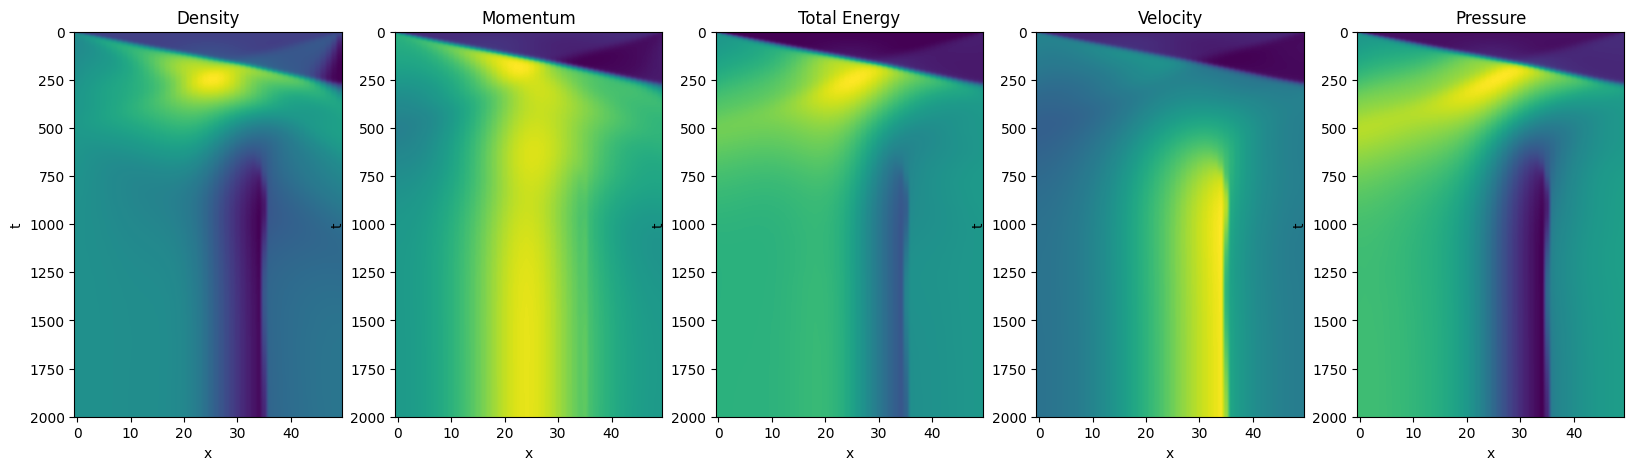

In [10]:
fig, ax = plt.subplots(1,5, figsize=(20,5))

iax = 0
ax[iax].imshow(uuc[:,0,:], aspect="auto")
# ax[0].set_colorbar()
ax[iax].set_xlabel('x')
ax[iax].set_ylabel('t')
ax[iax].set_title('Density')

iax = 1
ax[iax].imshow(uuc[:,1,:], aspect="auto")
# ax[0].set_colorbar()
ax[iax].set_xlabel('x')
ax[iax].set_ylabel('t')
ax[iax].set_title('Momentum')

iax = 2
ax[iax].imshow(uuc[:,2,:], aspect="auto")
# ax[0].set_colorbar()
ax[2].set_xlabel('x')
ax[iax].set_ylabel('t')
ax[iax].set_title('Total Energy')

iax = 3
ax[iax].imshow(uuc[:,1,:]/uuc[:,0,:], aspect="auto")
# ax[0].set_colorbar()
ax[iax].set_xlabel('x')
ax[iax].set_ylabel('t')
ax[iax].set_title('Velocity')

# pressure
# p = (gamma-1) * ( Et - .5 * m^2 / rho )
iax = 4
ax[iax].imshow(S.gamma_1 * (uuc[:,2,:]-.5*uuc[:,1,:]**2/uuc[:,0,:]), aspect="auto")
# ax[0].set_colorbar()
ax[iax].set_xlabel('x')
ax[iax].set_ylabel('t')
ax[iax].set_title('Pressure')


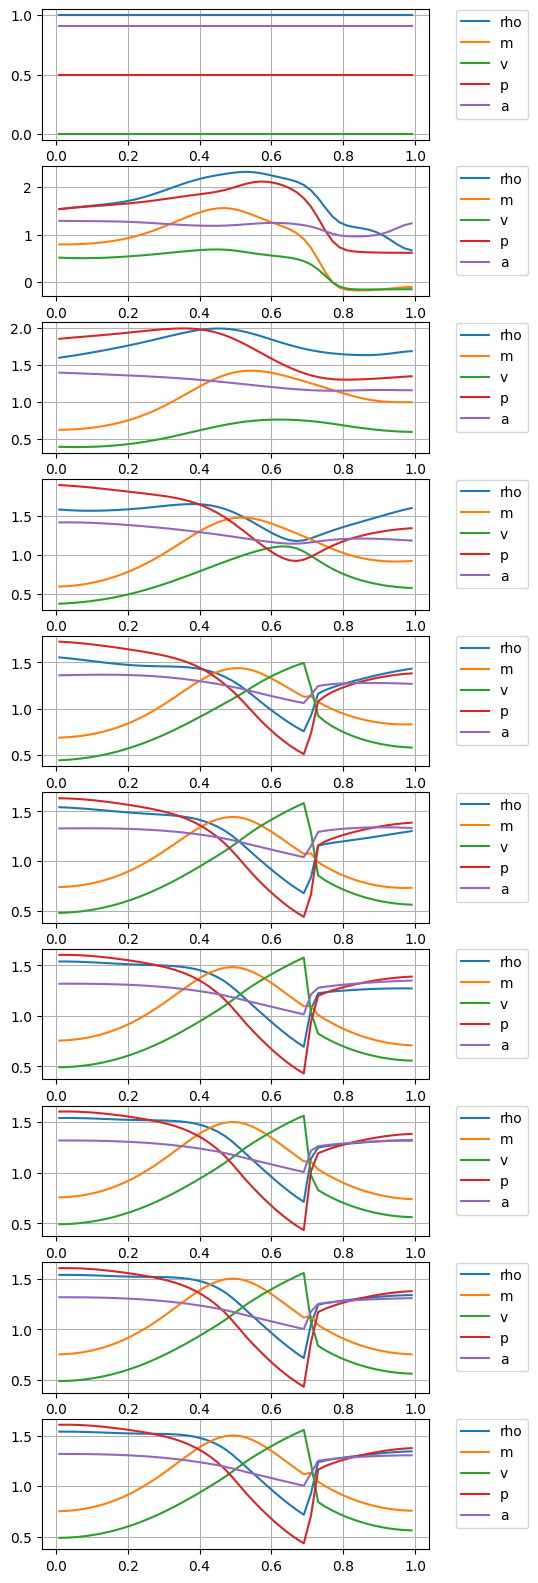

In [11]:
n_plots = 10
i_dt = int(np.floor(nt/n_plots))

fig, ax = plt.subplots(n_plots, figsize=(5,20))
for i in range(n_plots):
    p = S.gamma_1 * (uuc[i_dt*i,2,:]-.5*uuc[i_dt*i,1,:]**2/uuc[i_dt*i,0,:])
    ax[i].plot(xc,uuc[i_dt*i,0,:], label="rho")
    ax[i].plot(xc,uuc[i_dt*i,1,:], label="m")
    # ax[i].plot(xc,uuc[i_dt*i,2,:], label='Et')
    ax[i].plot(xc,uuc[i_dt*i,1,:]/uuc[i_dt*i,0,:], label="v")
    ax[i].plot(xc, p, label="p")
    ax[i].plot(xc, np.sqrt(S.gamma * p / uuc[i_dt*i,0,:]), label="a")

    ax[i].grid()
    ax[i].legend(bbox_to_anchor=(1.05, 1.05), loc='upper left')

# Pressure: p = (gamma-1) * ( Et - .5 * m^2 / rho )
# rho, m, Et = 1, 1, 2
# gamma = 5/3
# -> u = 1
# -> p = 2/3 * ( 2 - .5 * 1 ) = 2 / 3 * 1.5 = 1